In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/processed/clean_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Quarter,Month,Month Name,Day,Shipping Days,Profit Margin %,Loss Order,Discount Category,Sales Category,Order Size
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,4,11,November,Tuesday,3,16.00,No,No Discount,Medium,Small Order
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,4,11,November,Tuesday,3,30.00,No,No Discount,High,Small Order
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2,6,June,Sunday,4,47.00,No,No Discount,Low,Small Order
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,4,10,October,Sunday,7,-40.00,Yes,High,High,Small Order
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,4,10,October,Sunday,7,11.25,No,Low,Low,Small Order


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 9994
Columns : 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9994 non-null   int64  
 1   Order ID           9994 non-null   object 
 2   Order Date         9994 non-null   object 
 3   Ship Date          9994 non-null   object 
 4   Ship Mode          9994 non-null   object 
 5   Customer ID        9994 non-null   object 
 6   Customer Name      9994 non-null   object 
 7   Segment            9994 non-null   object 
 8   Country            9994 non-null   object 
 9   City               9994 non-null   object 
 10  State              9994 non-null   object 
 11  Postal Code        9994 non-null   int64  
 12  Region             9994 non-null   object 
 13  Product ID         9994 non-null   object 
 14  Category           9994 non-null   object 
 15  Sub-Category       9994 non-null   object 
 16 

In [5]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Profit Margin :", round(profit_margin,2), "%")
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)

Total Sales : 2297200.86
Total Profit : 286397.02
Profit Margin : 12.47 %
Total Orders : 5009
Total Customers : 793


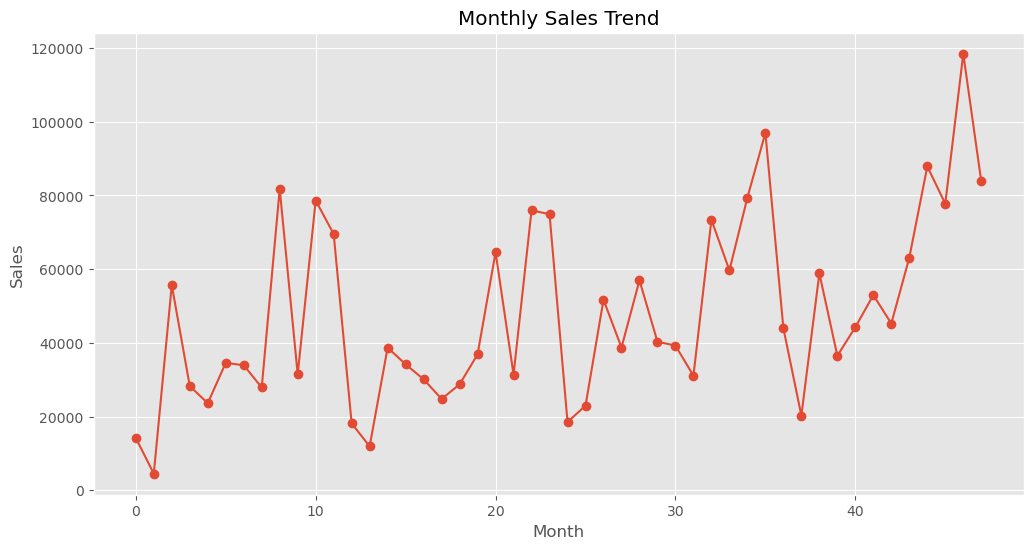

In [6]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales["Sales"], marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

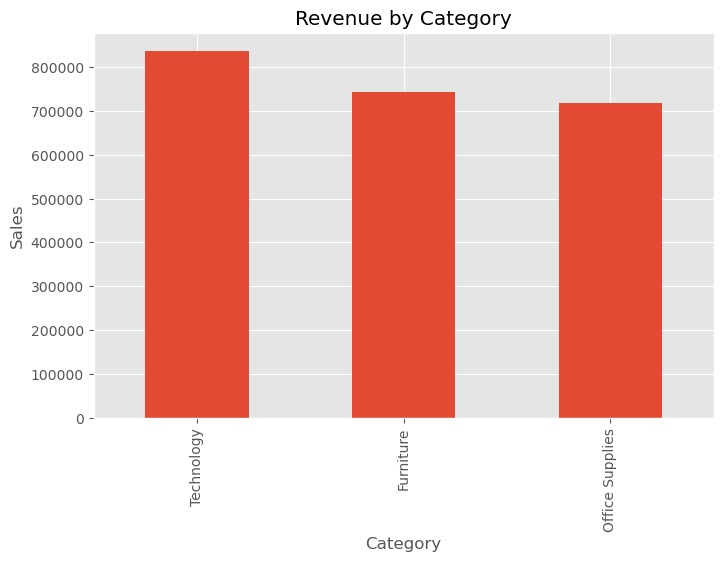

In [7]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")

plt.ylabel("Sales")

plt.show()

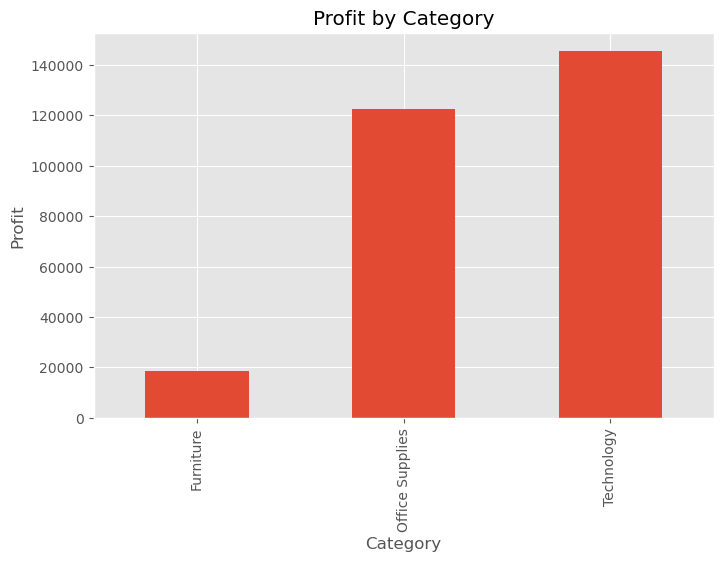

In [8]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
)

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")

plt.ylabel("Profit")

plt.show()

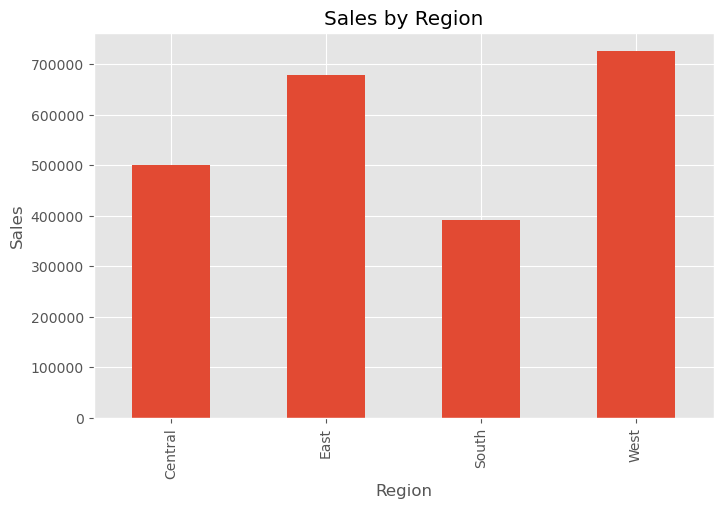

In [9]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")

plt.ylabel("Sales")

plt.show()

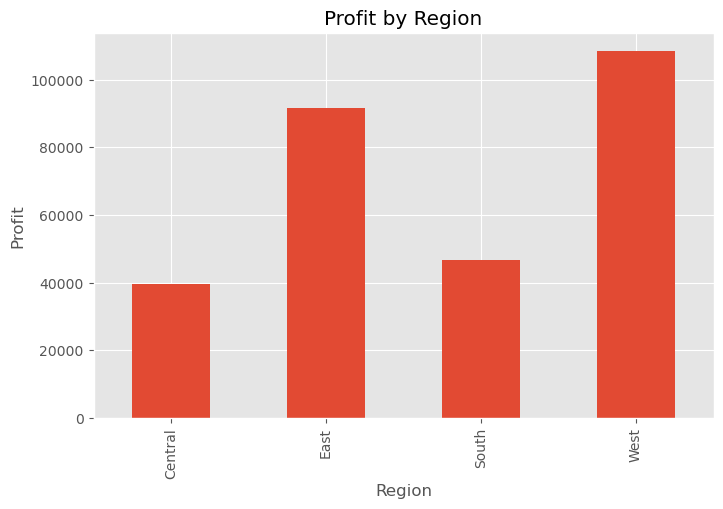

In [10]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
)

plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")

plt.ylabel("Profit")

plt.show()

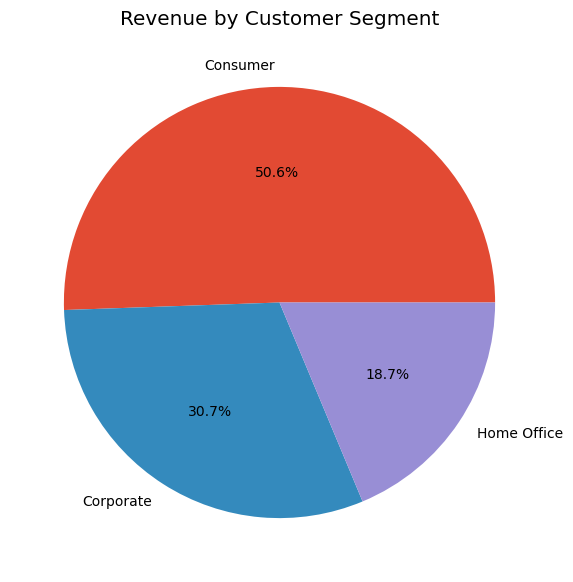

In [11]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Revenue by Customer Segment")

plt.show()

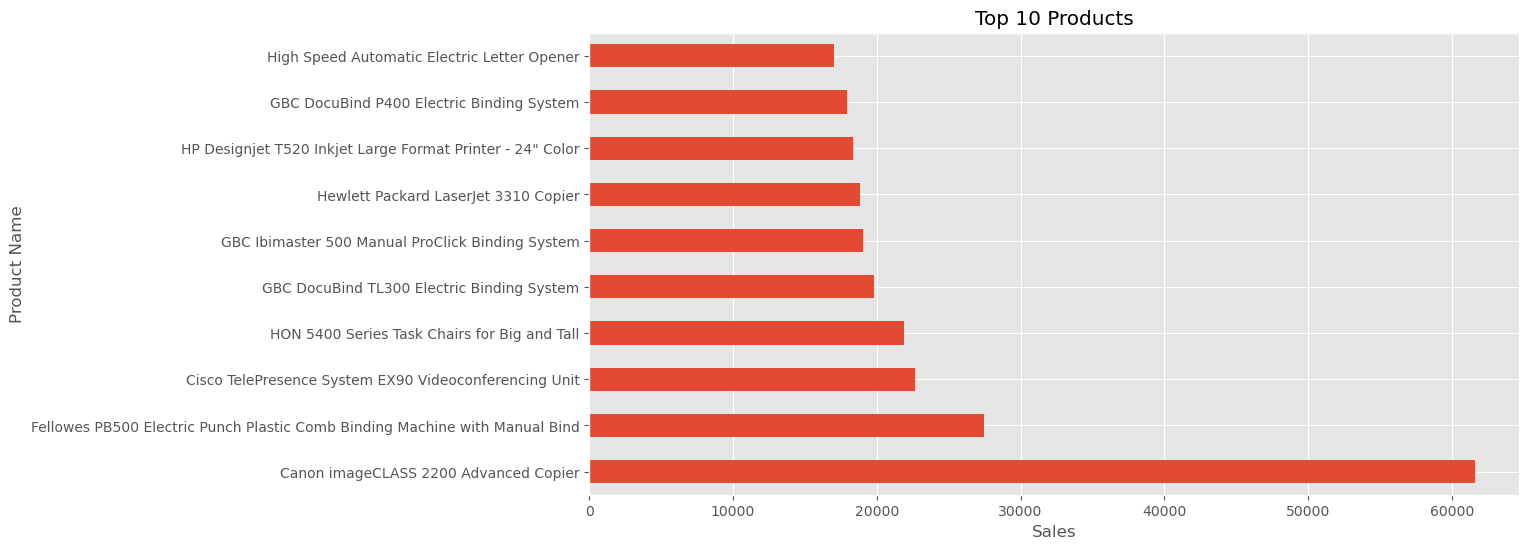

In [12]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.xlabel("Sales")

plt.show()

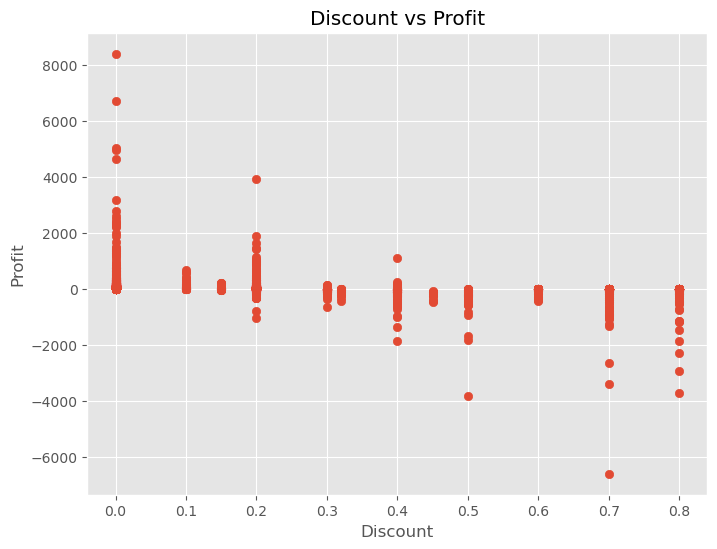

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

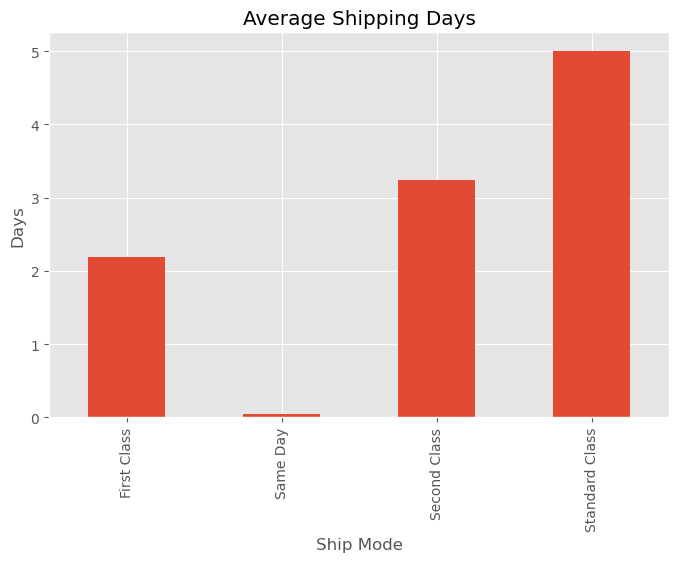

In [14]:
shipping = (
    df.groupby("Ship Mode")["Shipping Days"]
    .mean()
)

plt.figure(figsize=(8,5))

shipping.plot(kind="bar")

plt.title("Average Shipping Days")

plt.ylabel("Days")

plt.show()

In [15]:
correlation = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Shipping Days"
    ]
].corr()

print(correlation)

                  Sales  Quantity  Discount    Profit  Shipping Days
Sales          1.000000  0.200795 -0.028190  0.479064      -0.007354
Quantity       0.200795  1.000000  0.008623  0.066253       0.018298
Discount      -0.028190  0.008623  1.000000 -0.219487       0.000408
Profit         0.479064  0.066253 -0.219487  1.000000      -0.004649
Shipping Days -0.007354  0.018298  0.000408 -0.004649       1.000000


In [16]:
df.to_csv("data/processed/final_superstore.csv", index=False)